# Phase 1: How Misinformation and True Content Spread Differently

This notebook demonstrates the **two structural patterns of information propagation** that are
the empirical foundation of the InfoGuard paper.

The paper's central claim (Section 3.2) is:

> *"User polarization and reflexivity are thought to be the main drivers of the difference
> in cascade behaviors of misinformation and correct information."*

In practice this produces two visually distinct tree shapes:

| Pattern | Misinformation / False | True / Verified content |
|---|---|---|
| **Shape** | Wide star — one root, hundreds of direct shares | Deep chain — content re-verified at each hop |
| **Max depth** | 1–2 | 4–7 |
| **Max width** | Hundreds of nodes at depth 1 | A handful of nodes at any depth |
| **Branching factor** | High (each node infects many) | Low (each node infects 1–2) |
| **Paper term** | High branching ratio | Propagates to deeper `It` sets |

These differences are what **BiGCN learns to classify** and what the **LP optimizer exploits**
to suppress false content without banning it explicitly.

Run `explore_data.ipynb` first to generate the summary CSV files this notebook reads.


In [1]:
from pathlib import Path
from collections import Counter, defaultdict, deque
import re
import math
import random
import sys
import importlib.util

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt


def _load_project_config():
    """Load the central configuration object from the project root.

    Preferred filename is config.py. The fallback supports the uploaded
    config(1).py name used in this chat, so the notebook is runnable here too.
    """
    search_dirs = [Path.cwd(), Path.cwd().parent, Path('/mnt/data')]
    names = ['config.py', 'config(1).py']
    for base in search_dirs:
        for name in names:
            path = base / name
            if path.exists():
                if str(base) not in sys.path:
                    sys.path.insert(0, str(base))
                if name == 'config.py':
                    from config import cfg, ROOT as CONFIG_ROOT
                    return cfg, CONFIG_ROOT, path
                spec = importlib.util.spec_from_file_location('project_config', path)
                module = importlib.util.module_from_spec(spec)
                sys.modules[spec.name] = module
                spec.loader.exec_module(module)
                return module.cfg, module.ROOT, path
    raise FileNotFoundError(
        'Could not find config.py. Place config.py in the project root, '
        'start Jupyter from the project root, or keep config(1).py next to this notebook.'
    )

cfg, CONFIG_ROOT, CONFIG_PATH = _load_project_config()

RANDOM_SEED = cfg.seed
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

PROJECT_ROOT = Path(CONFIG_ROOT).resolve()
EVAL_DIR     = cfg.paths.evaluation
SUMMARY_PATH = EVAL_DIR / 'propagation_tree_summary.csv'
SAMPLES_PATH = EVAL_DIR / 'sample_tree_ids.csv'
FIG_DIR      = EVAL_DIR / 'tree_figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f'Config loaded from: {CONFIG_PATH}')
print(f'Project root: {PROJECT_ROOT}')
print(f'Evaluation directory: {EVAL_DIR}')
print(f'Figure directory: {FIG_DIR}')


Config loaded from: /home/krmsh1n5/Desktop/UFAZ/infoshield/config.py
Project root: /home/krmsh1n5/Desktop/UFAZ/infoshield
Evaluation directory: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation
Figure directory: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures


## 1. Load the Phase 1 catalog

`explore_data.ipynb` produces two CSV files used here:

- `propagation_tree_summary.csv` — stats for every cascade (4 000+ rows)
- `contrast_tree_ids.csv` — the best contrasting examples selected by depth/width criteria

If `contrast_tree_ids.csv` is absent the notebook falls back to searching
`propagation_tree_summary.csv` directly.


In [2]:
if not SUMMARY_PATH.exists():
    raise FileNotFoundError(f'Missing {SUMMARY_PATH}. Run explore_data.ipynb first.')

_STR_COLS = {'tweet_id': str, 'content_id': str, 'root_user': str, 'label': str,
             'raw_label': str, 'text': str, 'graph_path': str}
_SUMMARY_COLS = [
    'dataset','tweet_id','content_id','root_user','label','raw_label',
    'graph_path','text','num_nodes','num_edges','cascade_size','max_depth',
    'max_width','branching_ratio','num_roots','is_arborescence','temporal_span'
]

def _read_csv(path, cols):
    try:
        df = pd.read_csv(path, dtype=_STR_COLS)
    except pd.errors.EmptyDataError:
        df = pd.DataFrame(columns=cols)
    for col in cols:
        if col not in df.columns:
            df[col] = pd.Series(dtype='object')
    for num_col in ['cascade_size','max_depth','max_width','branching_ratio',
                    'num_edges','num_nodes','temporal_span']:
        if num_col in df.columns:
            df[num_col] = pd.to_numeric(df[num_col], errors='coerce')
    df['label'] = df['label'].astype(str).str.lower().str.strip()
    return df

tree_summary  = _read_csv(SUMMARY_PATH, _SUMMARY_COLS)

CONTRAST_PATH = EVAL_DIR / 'contrast_tree_ids.csv'
if CONTRAST_PATH.exists():
    contrast_trees = _read_csv(CONTRAST_PATH, _SUMMARY_COLS)
else:
    # Fall back: search tree_summary ourselves
    tw = tree_summary[tree_summary['dataset'].isin(['Twitter15','Twitter16'])]
    true_ex  = tw[tw['label'].eq('true') & tw['graph_path'].notna()
                  ].sort_values('max_depth', ascending=False).head(3)
    false_ex = tw[tw['label'].eq('false') & tw['graph_path'].notna()
                  ].sort_values('max_width', ascending=False).head(3)
    contrast_trees = pd.concat([true_ex, false_ex], ignore_index=True)
    print('contrast_tree_ids.csv not found — searched tree_summary directly.')

if SAMPLES_PATH.exists():
    sample_trees = _read_csv(SAMPLES_PATH, _SUMMARY_COLS)
else:
    sample_trees = contrast_trees.copy()

print(f'Summary rows:        {len(tree_summary)}')
print(f'Contrast examples:   {len(contrast_trees)}')
print(f'Sample rows:         {len(sample_trees)}')
_dc = ['dataset','tweet_id','label','cascade_size','max_depth','max_width','graph_path']
display(contrast_trees[_dc])


Summary rows:        4765
Contrast examples:   6
Sample rows:         6


,dataset,tweet_id,label,cascade_size,max_depth,max_width,graph_path
0,Twitter16,763964234774347776,true,1178,12,784,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/ra...
1,Twitter15,641665203046907904,true,642,12,338,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/ra...
2,Twitter15,764620072228970496,true,817,11,292,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/ra...
3,Twitter15,524320261667950592,false,679,2,657,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/ra...
4,Twitter15,507634536176300032,false,522,2,495,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/ra...
5,Twitter15,387009577763360768,false,476,2,449,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/ra...


## 2. Tree parsing helpers

These are repeated so this notebook can reload graph files directly from the paths saved by the exploration notebook.

In [3]:
def normalize_id(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    if not s or s.lower() in {'nan', 'none', 'null'}:
        return None
    if re.fullmatch(r'\d+\.0', s):
        s = s[:-2]
    return s


def parse_edge_line(line):
    """Parse one edge line from a Twitter15/16 tree file.

    Returns (parent_uid, child_uid, delay_float) or None.
    parent_uid may be 'ROOT' for the sentinel line.
    """
    raw = line.strip()
    if not raw or '->' not in raw:
        return None
    halves = raw.split('->', 1)
    if len(halves) != 2:
        return None

    def extract_fields(s):
        return re.findall(r"'([^']*?)'", s)

    parent_fields = extract_fields(halves[0])
    child_fields  = extract_fields(halves[1])
    if not parent_fields or not child_fields:
        return None
    parent_uid = normalize_id(parent_fields[0])
    child_uid  = normalize_id(child_fields[0])
    delay = None
    if len(child_fields) >= 3:
        try:
            delay = float(child_fields[2])
        except ValueError:
            pass
    return parent_uid, child_uid, delay


def graph_from_edges(edge_rows, root_sentinel=None):
    """Build (DiGraph, root_user_id) from (parent_uid, child_uid, delay) tuples.

    ROOT sentinel identifies the source user as root_user_id.
    No phantom ROOT node is added; all nodes stay in user-ID namespace.

    root_sentinel defaults to cfg.twitter15.root_sentinel ('ROOT').
    Pass cfg.twitter16.root_sentinel when loading Twitter16 trees.
    """
    if root_sentinel is None:
        root_sentinel = cfg.twitter15.root_sentinel  # both datasets use 'ROOT'
    G = nx.DiGraph()
    root_user_id = None
    for parent, child, delay in edge_rows:
        parent = normalize_id(parent)
        child  = normalize_id(child)
        if parent is None or child is None:
            continue
        if parent.upper() == root_sentinel.upper():
            if root_user_id is None:
                root_user_id = child
            G.add_node(child)
        else:
            G.add_edge(parent, child)
            if delay is not None:
                G.nodes[child]['delay'] = delay
    return G, root_user_id


def _wico_find_root(G, nodes_df):
    """Most-followed user in nodes.csv that appears in G, else highest in-degree."""
    if not nodes_df.empty and 'id' in nodes_df.columns:
        if 'followers' in nodes_df.columns:
            cands = nodes_df[nodes_df['id'].map(normalize_id).isin(G.nodes)].copy()
            if not cands.empty:
                try:
                    cands['followers'] = pd.to_numeric(cands['followers'], errors='coerce')
                    best = cands.loc[cands['followers'].idxmax(), 'id']
                    bid  = normalize_id(best)
                    if bid in G:
                        return bid
                except Exception:
                    pass
        for _, nr in nodes_df.iterrows():
            nid = normalize_id(nr.get('id'))
            if nid and nid in G:
                return nid
    if G.number_of_nodes() > 0:
        return max(G.nodes, key=lambda n: G.in_degree(n))
    return None


def load_graph_for_row(row):
    """Reconstruct a DiGraph from a catalog row.

    graph_path may be:
      - A .txt file : Twitter15/16 tree file
      - A directory : WICO Graph per-tweet folder (edges.txt + nodes.csv)

    Returns (G, root_user_id).
    """
    graph_path = row.get('graph_path')
    if not graph_path or pd.isna(graph_path):
        raise ValueError('No graph_path in row')
    path     = Path(str(graph_path))
    # root_user column is present in CSVs generated by the fixed explore_data
    stored_root = normalize_id(row.get('root_user'))

    if not path.exists():
        raise FileNotFoundError(path)

    # ── WICO Graph: graph_path is a directory ────────────────────────────
    if path.is_dir():
        edges_path = path / cfg.wico.graph_edges_file
        G = nx.DiGraph()
        if edges_path.exists():
            for line in edges_path.read_text(errors='ignore').splitlines():
                parts = line.strip().split()
                if len(parts) == 2:
                    src, dst = normalize_id(parts[0]), normalize_id(parts[1])
                    if src and dst:
                        G.add_edge(src, dst)
        nodes_path = path / cfg.wico.graph_nodes_file
        nodes_df   = pd.DataFrame()
        if nodes_path.exists():
            nodes_df = pd.read_csv(nodes_path, dtype=str)
            nodes_df.columns = [c.strip().lower() for c in nodes_df.columns]
            # Use cfg.wico.graph_nodes_columns as source of truth for feature names
            _feat_cols = [c for c in cfg.wico.graph_nodes_columns if c != 'id']
            for _, nr in nodes_df.iterrows():
                nid = normalize_id(nr.get('id'))
                if nid:
                    G.add_node(nid)
                    for feat in _feat_cols:
                        try:
                            G.nodes[nid][feat] = int(float(nr[feat]))
                        except (ValueError, KeyError, TypeError):
                            pass
        # FIX: prefer stored root (from explore_data CSV); fall back to heuristic
        root_user_id = (stored_root if stored_root and stored_root in G
                        else _wico_find_root(G, nodes_df))
        return G, root_user_id

    # ── Twitter15/16: graph_path is a .txt tree file ─────────────────────
    # Use cfg.twitter15.root_sentinel; Twitter16 uses the same value ('ROOT')
    edge_rows = []
    for line in path.read_text(errors='ignore').splitlines():
        parsed = parse_edge_line(line)
        if parsed:
            edge_rows.append(parsed)
    G, root_user_id = graph_from_edges(edge_rows, root_sentinel=cfg.twitter15.root_sentinel)
    # Prefer the stored root_user from the CSV if available and present in G
    if stored_root and stored_root in G:
        root_user_id = stored_root
    return G, root_user_id


def make_synthetic_tree(label, n_nodes=40, seed=0):
    """Generate a synthetic propagation tree for demo/fallback use.

    False trees are wide and shallow (burst spreading).
    True trees are narrow and deep (chain verification).
    Temporal delays are attached to nodes to enable timeline plots.
    """
    rng = np.random.default_rng(seed)
    G = nx.DiGraph()
    root = 'u0'
    G.add_node(root)
    G.nodes[root]['delay'] = 0.0
    queue = [root]
    uid   = 1
    if label == 'false':
        # Wide bursts: each node fans out to 3-6 children quickly
        while queue and uid < n_nodes:
            parent = queue.pop(0)
            fan    = int(rng.integers(3, 7))
            parent_delay = G.nodes[parent].get('delay', 0)
            for _ in range(fan):
                if uid >= n_nodes:
                    break
                child = f'u{uid}'
                delay = parent_delay + float(rng.exponential(2))
                G.add_edge(parent, child)
                G.nodes[child]['delay'] = delay
                queue.append(child)
                uid += 1
    else:
        # Deep chains: each node has 1-2 children, grows slowly
        while queue and uid < n_nodes:
            parent = queue.pop(0)
            fan    = int(rng.integers(1, 3))
            parent_delay = G.nodes[parent].get('delay', 0)
            for _ in range(fan):
                if uid >= n_nodes:
                    break
                child = f'u{uid}'
                delay = parent_delay + float(rng.exponential(8))
                G.add_edge(parent, child)
                G.nodes[child]['delay'] = delay
                queue.append(child)
                uid += 1
    return G, root

print('Helpers defined.')


Helpers defined.


## 3. Layout and plotting helpers

The plots highlight the root node and show the outward reshare structure. For very large cascades, only the first few hundred nodes are drawn to keep the visualization readable.

In [4]:
def find_root(G, preferred=None):
    preferred = normalize_id(preferred)
    if preferred and preferred in G:
        return preferred
    roots = [n for n in G.nodes if G.in_degree(n) == 0]
    return roots[0] if roots else (next(iter(G.nodes)) if G.number_of_nodes() else None)


def depth_subgraph(G, root, max_nodes=250):
    if root is None or root not in G:
        return G.copy(), {}
    depths = nx.single_source_shortest_path_length(G, root)
    nodes  = sorted(depths, key=lambda n: (depths[n], str(n)))[:max_nodes]
    H      = G.subgraph(nodes).copy()
    return H, {n: depths[n] for n in H.nodes}

def depth_subgraph_sampled(G, root, max_per_depth=25):
    """Sample nodes per depth level so ALL depth levels stay visible.

    Unlike depth_subgraph(max_nodes=N) which fills the budget top-down
    (cutting off deep levels entirely), this function keeps every level
    but shows at most max_per_depth representative nodes per level.
    Nodes with the highest out-degree are kept — they are the most
    influential spreaders and carry the most structural signal.
    """
    if root is None or root not in G:
        return G.copy(), {}
    full_depths = nx.single_source_shortest_path_length(G, root)
    by_depth = defaultdict(list)
    for n, d in full_depths.items():
        by_depth[d].append(n)
    selected = []
    for d in sorted(by_depth.keys()):
        nodes = by_depth[d]
        if len(nodes) <= max_per_depth:
            selected.extend(nodes)
        else:
            # Keep the most-connected nodes: they infected the most users
            nodes_sorted = sorted(nodes,
                                  key=lambda n: G.out_degree(n), reverse=True)
            selected.extend(nodes_sorted[:max_per_depth])
    H = G.subgraph(selected).copy()
    return H, {n: full_depths[n] for n in H.nodes}


def hierarchy_positions(G, root=None):
    root = find_root(G, root)
    if root is None:
        return {}
    depths   = nx.single_source_shortest_path_length(G, root)
    by_depth = defaultdict(list)
    for n, d in depths.items():
        by_depth[d].append(n)
    pos = {}
    for d, nodes_at_d in by_depth.items():
        nodes_at_d = sorted(nodes_at_d, key=str)
        width = max(1, len(nodes_at_d) - 1)
        for i, n in enumerate(nodes_at_d):
            pos[n] = (i / width - 0.5 if width else 0, -d)
    for i, n in enumerate(n for n in G.nodes if n not in pos):
        pos[n] = (0.75 + (i % 10) * 0.06, -(i // 10))
    return pos


def draw_tree_on_ax(ax, G, root=None, color='#7F77DD', max_nodes=250, title=''):
    """Draw a propagation tree on an existing Axes object."""
    H, depths = depth_subgraph(G, root, max_nodes=max_nodes)
    pos = hierarchy_positions(H, root)
    if not pos:
        ax.text(0.5, 0.5, '(empty graph)', ha='center', va='center',
                transform=ax.transAxes, fontsize=9, color='gray')
        ax.set_visible(True)
        if title:
            ax.set_title(title, fontsize=8)
        ax.axis('off')
        return H, depths, pos

    out_deg  = dict(H.out_degree())
    max_deg  = max(out_deg.values()) if out_deg else 1
    sizes    = [120 + 500 * (out_deg.get(n, 0) / max(max_deg, 1)) for n in H.nodes()]
    node_colors = [color if n != root else '#222222' for n in H.nodes()]

    nx.draw_networkx_edges(H, pos, ax=ax, edge_color='#cccccc',
                           arrows=True, arrowsize=8, width=0.6, alpha=0.7)
    nx.draw_networkx_nodes(H, pos, ax=ax, node_color=node_colors,
                           node_size=sizes, alpha=0.88)
    if root and root in pos:
        ax.scatter(*pos[root], s=300, facecolors='none',
                   edgecolors='black', linewidths=2, zorder=5)
    if title:
        ax.set_title(title, fontsize=8)
    ax.axis('off')
    return H, depths, pos


def plot_depth_profile(G, title, root=None):
    root = find_root(G, root)
    if root is None:
        return
    depths = nx.single_source_shortest_path_length(G, root)
    counts = Counter(depths.values())
    xs, ys = zip(*sorted(counts.items())) if counts else ([], [])
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(xs, ys, color='#7F77DD', edgecolor='white')
    ax.set_xlabel('Depth from root')
    ax.set_ylabel('Nodes at depth')
    ax.set_title(title, fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    safe = re.sub(r'[^A-Za-z0-9_.\-]+', '_', title)[:100]
    out  = FIG_DIR / f'depth_{safe}.png'
    plt.savefig(out, dpi=150)
    plt.show()
    print('Saved:', out)

print('Layout helpers defined.')


Layout helpers defined.


## 2. The Two Patterns of Information Spreading

The fundamental insight from the paper is that **false content bursts outward immediately**
while **true content propagates in verified chains**.

### Why this happens (from the paper, Section 3.2)

False content exploits **low reflexivity** — users share without checking, causing a single
root tweet to infect hundreds of users at depth 1 in the first minutes.  No verification
chain forms because nobody pauses to question it.

True content experiences **higher reflexivity and cross-polarization resistance**.  Users
share within small trusted groups; each hop is a deliberate re-endorsement.  This creates
deeper but narrower propagation trees.

### What you will see
- **Left column (False / Misinformation):** A star-shaped tree — root connected directly to
  hundreds of leaves, max depth ≤ 2.  Every leaf is an `It` node that received the content
  in the first SIR iteration and never re-shared further.
- **Right column (True / Verified):** A spine tree — content travels through 5–7 levels of
  re-sharing, with a small number of nodes at each depth.  The branching factor stays close
  to 1–2 per node.

> **Paper connection:** the b⁻ matrix (false content SBM) has high off-diagonal entries
> because false content crosses polarization classes quickly.  The b⁺ matrix (true content)
> has stronger diagonal entries because true content propagates within communities.


In [5]:
# ── Find the single best representative of each pattern ──────────────────
# We search the full tree_summary (thousands of trees) to find:
#   TRUE : the deepest reachable tree (max_depth as large as possible)
#   FALSE: the widest shallowest tree (max_width high, max_depth low)
# Both from Twitter15/16, which have genuine retweet-chain structure.

def _pick_best(df, label, sort_col, ascending=False, min_depth=None, max_depth=None,
               min_width=None, fallback_col=None):
    """Pick the single best cascade matching the criteria."""
    mask = (df['label'].eq(label) & df['graph_path'].notna()
            & df['dataset'].isin(['Twitter15','Twitter16']))
    if min_depth  is not None: mask &= df['max_depth'].ge(min_depth)
    if max_depth  is not None: mask &= df['max_depth'].le(max_depth)
    if min_width  is not None: mask &= df['max_width'].ge(min_width)
    sub = df[mask].sort_values(sort_col, ascending=ascending)
    if sub.empty and fallback_col:
        sub = df[df['label'].eq(label) & df['graph_path'].notna()
                 ].sort_values(fallback_col, ascending=ascending)
    return sub.iloc[0] if not sub.empty else None

# Best TRUE example: deepest tree
best_true  = _pick_best(tree_summary, 'true',  'max_depth', ascending=False,
                        min_depth=4, fallback_col='max_depth')
# Best FALSE example: widest star (max_width high, max_depth <= 3)
best_false = _pick_best(tree_summary, 'false', 'max_width',  ascending=False,
                        max_depth=3, min_width=30, fallback_col='max_width')

# Load graphs
contrast_loaded = {}   # {'true': (row, G, root), 'false': (row, G, root)}

for label, best_row in [('true', best_true), ('false', best_false)]:
    if best_row is None:
        print(f'No {label} example found in tree_summary.')
        continue
    try:
        G, root = load_graph_for_row(best_row.to_dict())
        contrast_loaded[label] = (best_row.to_dict(), G, root)
        depths     = nx.single_source_shortest_path_length(G, root) if root and root in G else {}
        depth_dist = Counter(depths.values())
        non_leaf   = [d for _, d in G.out_degree() if d > 0]
        print(f'\n{label.upper()} example — {best_row.get("dataset")} '
              f'tweet {best_row.get("tweet_id")}')
        print(f'  Text            : "{str(best_row.get("text",""))[:90]}"')
        print(f'  Nodes           : {G.number_of_nodes()}')
        print(f'  Edges           : {G.number_of_edges()}')
        print(f'  Max depth       : {max(depth_dist) if depth_dist else 0}')
        print(f'  Nodes per depth : {dict(sorted(depth_dist.items()))}')
        avg_b = f"{np.mean(non_leaf):.2f}" if non_leaf else 'N/A'
        print(f'  Avg branching   : {avg_b}')
    except Exception as e:
        print(f'Could not load {label} tree: {e}')

if len(contrast_loaded) < 2:
    print('\nUsing synthetic demo trees as fallback.')
    for label in ['false','true']:
        if label not in contrast_loaded:
            G, root = make_synthetic_tree(label, n_nodes=60, seed=99)
            row = {'dataset':'Synthetic','tweet_id':f'demo_{label}','label':label,
                   'text':f'[synthetic {label} demo]','graph_path':None,
                   'cascade_size':G.number_of_nodes()}
            contrast_loaded[label] = (row, G, root)



TRUE example — Twitter15 tweet 641665203046907904
  Text            : "apple just invented the pencil. #appleevent URL"
  Nodes           : 642
  Edges           : 642
  Max depth       : 12
  Nodes per depth : {0: 1, 1: 338, 2: 136, 3: 43, 4: 47, 5: 23, 6: 17, 7: 11, 8: 11, 9: 6, 10: 4, 11: 4, 12: 1}
  Avg branching   : 5.06

FALSE example — Twitter15 tweet 560442390805090307
  Text            : "drift into a peaceful slumber w/@thejeffbridges' new #sleepingtapes album. listen now at U"
  Nodes           : 1748
  Edges           : 1781
  Max depth       : 3
  Nodes per depth : {0: 1, 1: 1583, 2: 157, 3: 7}
  Avg branching   : 14.84


## 3. Side-by-Side: False (Wide Star) vs True (Deep Chain)

Each tree is drawn with a **hierarchical layout** — the root is at the top and each row
below is one additional hop (SIR iteration) from the root.

- **Node size** scales with out-degree: bigger nodes infected more users downstream.
- **Node color** darkens with depth: lighter nodes are closer to the root, darker nodes
  are further along the chain.
- **Black ring** marks the root tweet (the original claim).

Look at the y-axis depth lines on the left: for the false tree nearly all nodes crowd at
depth 1, while for the true tree nodes are spread across 5–7 rows.


/tmp/ipykernel_155129/117937414.py:134: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(w_pad=3)
/tmp/ipykernel_155129/117937414.py:134: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(w_pad=3)
/tmp/ipykernel_155129/117937414.py:136: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(out, dpi=150, bbox_inches='tight')
/tmp/ipykernel_155129/117937414.py:136: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(out, dpi=150, bbox_inches='tight')
/home/krmsh1n5/Desktop/UFAZ/infoshield/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/krmsh1n5/Desktop/UFAZ/infoshield/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WH

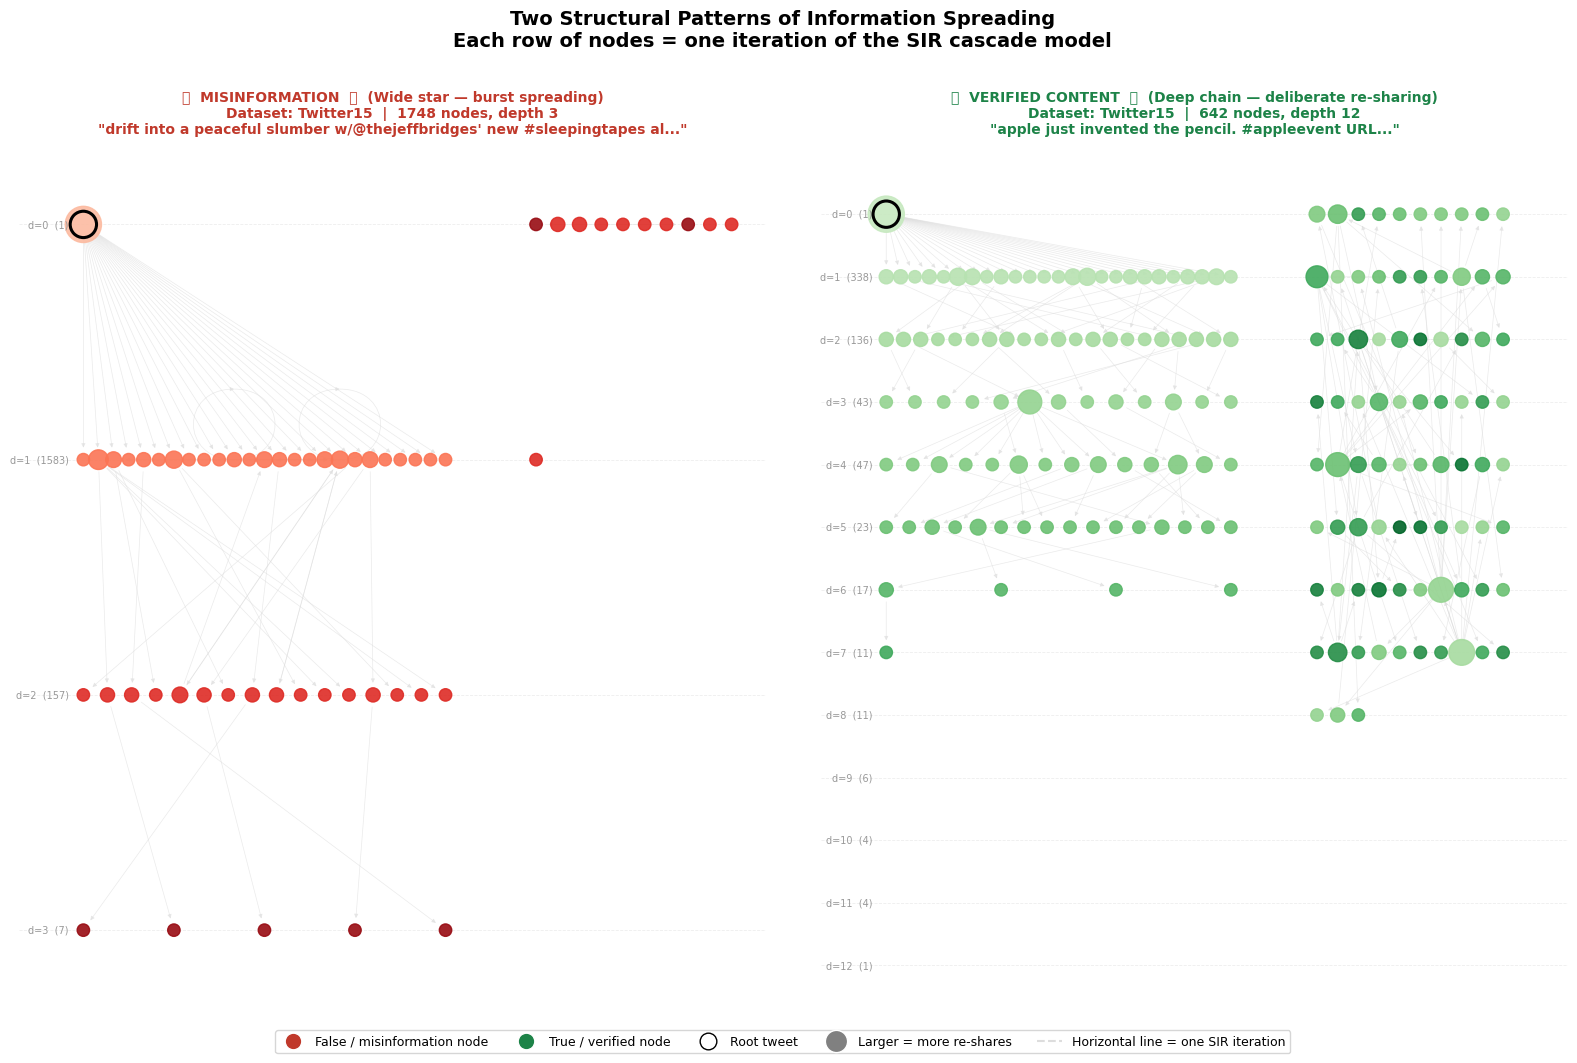

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/showcase_false_vs_true_spreading.png


In [6]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

def draw_contrast_tree(ax, G, root, label, max_per_depth=25):
    """
    Draw a propagation tree with depth-based node coloring.

    Uses depth_subgraph_sampled so every depth level is visible
    even for very wide trees (1000+ nodes at depth 1).
    Stats (max_depth, depth distribution) are computed from the
    FULL graph so titles and table values are never truncated.
    """
    # ── Full-graph stats (never truncated) ───────────────────────────────
    full_depths  = (nx.single_source_shortest_path_length(G, root)
                    if root and root in G else {})
    full_dist    = Counter(full_depths.values())
    max_d        = max(full_depths.values()) if full_depths else 0

    # ── Sampled subgraph for drawing (all levels, ≤max_per_depth each) ───
    H, draw_depths = depth_subgraph_sampled(G, root, max_per_depth=max_per_depth)
    pos = hierarchy_positions(H, root)

    if not pos:
        ax.text(0.5, 0.5, '(empty)', ha='center', va='center',
                transform=ax.transAxes, fontsize=10)
        ax.axis('off')
        return H, full_depths, full_dist, max_d

    cmap = cm.Reds if label == 'false' else cm.Greens
    node_colors = [
        cmap(0.25 + 0.65 * draw_depths.get(n, 0) / max(max_d, 1))
        for n in H.nodes()
    ]
    out_deg = dict(H.out_degree())
    max_deg = max(out_deg.values()) if out_deg else 1
    sizes   = [80 + 600 * (out_deg.get(n, 0) / max(max_deg, 1))
               for n in H.nodes()]

    # Depth-level guide lines — one per actual level in the FULL tree
    for d in range(max_d + 1):
        nodes_at_d = [n for n, dep in draw_depths.items() if dep == d]
        if nodes_at_d:
            y_val = -d
            ax.axhline(y=y_val, color='#eeeeee', linewidth=0.6,
                       linestyle='--', zorder=0)
            count_full = full_dist.get(d, 0)
            ax.text(-0.54, y_val,
                    f'd={d}  ({count_full})',   # shows real node count
                    fontsize=7, color='#999999', va='center', ha='right')

    nx.draw_networkx_edges(H, pos, ax=ax, edge_color='#dddddd',
                           arrows=True, arrowsize=6, width=0.5, alpha=0.6)
    nx.draw_networkx_nodes(H, pos, ax=ax, node_color=node_colors,
                           node_size=sizes, alpha=0.90)
    if root and root in pos:
        ax.scatter(*pos[root], s=360, facecolors='none',
                   edgecolors='black', linewidths=2.2, zorder=6)
    ax.axis('off')
    return H, full_depths, full_dist, max_d

# ── Build the hero figure ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 10))
fig.patch.set_facecolor('white')

COLORS = {'false': '#C0392B', 'true': '#1D8348'}
TITLE  = {
    'false': '❌  MISINFORMATION  ❌  (Wide star — burst spreading)',
    'true' : '✅  VERIFIED CONTENT  ✅  (Deep chain — deliberate re-sharing)',
}

stats_for_table = {}

for ax, label in zip(axes, ['false', 'true']):
    if label not in contrast_loaded:
        ax.text(0.5, 0.5, f'No {label} example loaded',
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.axis('off')
        continue

    row, G, root = contrast_loaded[label]
    H, full_depths, full_dist, max_d = draw_contrast_tree(
        ax, G, root, label, max_per_depth=25
    )

    non_leaf = [d for _, d in G.out_degree() if d > 0]
    # Use the corrected per-step branching ratio from tree_summary if available
    br_from_csv = pd.to_numeric(
        row.get('branching_ratio', None), errors='coerce')
    avg_br = (float(br_from_csv) if pd.notna(br_from_csv)
              else (round(float(np.mean(non_leaf)), 2) if non_leaf else 0))

    stats_for_table[label] = {
        'Nodes (cascade size)':   G.number_of_nodes(),
        'Edges (p_ij transfers)': G.number_of_edges(),
        'Max depth':              max_d,
        'Nodes at depth 1':       full_dist.get(1, 0),
        'Nodes at deepest level': full_dist.get(max_d, 0),
        'Avg branching factor':   avg_br,
        'Is strict tree':         nx.is_arborescence(G),
    }

    short_text = str(row.get('text', ''))[:70]
    ax.set_title(
        f'{TITLE[label]}\n'
        f'Dataset: {row.get("dataset","?")}  |  '
        f'{G.number_of_nodes()} nodes, depth {max_d}\n'
        f'"{short_text}..."',
        fontsize=10, fontweight='bold', color=COLORS[label], pad=12
    )

legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#C0392B',
           markersize=12, label='False / misinformation node'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#1D8348',
           markersize=12, label='True / verified node'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='none',
           markeredgecolor='black', markersize=12, label='Root tweet'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='gray',
           markersize=16, label='Larger = more re-shares'),
    Line2D([0],[0], color='#dddddd', linestyle='--', linewidth=1.5,
           label='Horizontal line = one SIR iteration'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=5,
           fontsize=9, bbox_to_anchor=(0.5, -0.04), frameon=True,
           edgecolor='#cccccc')

fig.suptitle(
    'Two Structural Patterns of Information Spreading\n'
    'Each row of nodes = one iteration of the SIR cascade model',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout(w_pad=3)
out = FIG_DIR / 'showcase_false_vs_true_spreading.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', out)


## 4. Structural Statistics: Numbers Behind the Patterns

The table below quantifies what the trees show visually.
Every row maps to a variable in the paper:

| Statistic | Paper variable | Role |
|---|---|---|
| Nodes (cascade size) | R∞ | What the LP optimizer minimises for false content |
| Avg branching factor | branching ratio | Must stay ≥ α for true content after dropouts |
| Max depth | SIR iterations | Deeper = more cascade steps = more LP optimization opportunities |
| Nodes at depth 1 | \|I₁\| | Burst size at first SIR step |


=== STRUCTURAL STATISTICS COMPARISON ===

                       FALSE (misinformation) TRUE (verified)
Nodes (cascade size)                     1748             642
Edges (p_ij transfers)                   1781             642
Max depth                                   3              12
Nodes at depth 1                         1583             338
Nodes at deepest level                      7               1
Avg branching factor                 1.912931             1.0
Is strict tree                          False           False


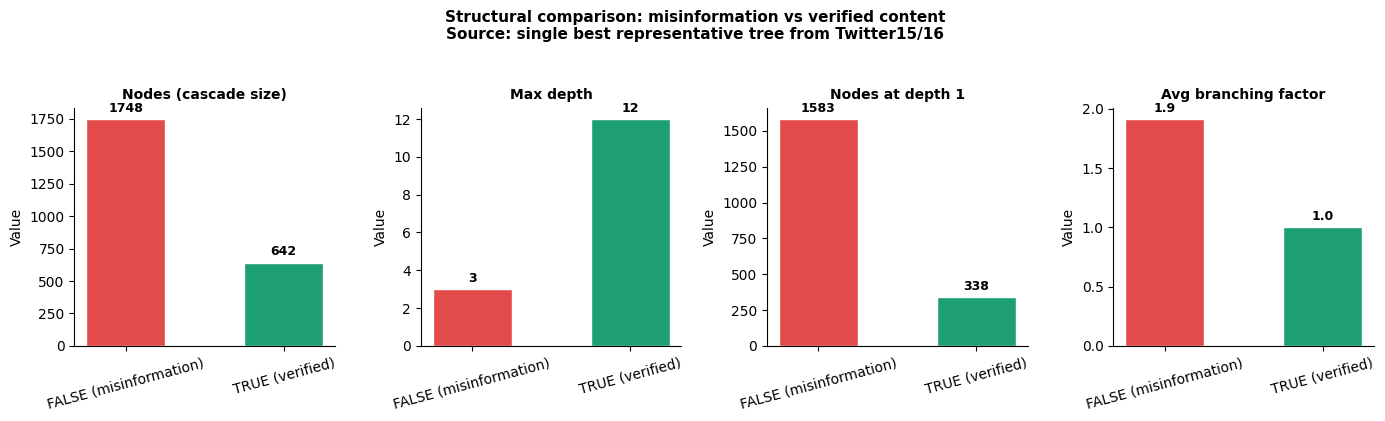

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/stats_comparison_false_vs_true.png


In [7]:
if stats_for_table:
    # ── Comparison table ─────────────────────────────────────────────────
    stats_df = pd.DataFrame(stats_for_table).rename(
        columns={'false': 'FALSE (misinformation)', 'true': 'TRUE (verified)'})
    print('=== STRUCTURAL STATISTICS COMPARISON ===\n')
    print(stats_df.to_string())

    # ── Bar chart: key metrics side by side ──────────────────────────────
    metrics = ['Nodes (cascade size)', 'Max depth',
               'Nodes at depth 1', 'Avg branching factor']
    available = [m for m in metrics if m in stats_df.index]

    fig, axes = plt.subplots(1, len(available), figsize=(14, 4))
    if len(available) == 1:
        axes = [axes]

    for ax, metric in zip(axes, available):
        vals   = [stats_df.loc[metric, col] for col in stats_df.columns
                  if col in stats_df.columns]
        colors = ['#E24B4A', '#1D9E75']
        bars   = ax.bar(stats_df.columns, vals, color=colors[:len(vals)],
                        edgecolor='white', width=0.5)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + max(vals)*0.02,
                    f'{val:.1f}' if isinstance(val, float) else str(val),
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax.set_title(metric, fontsize=10, fontweight='bold')
        ax.set_ylabel('Value')
        ax.spines[['top','right']].set_visible(False)
        ax.tick_params(axis='x', rotation=15)

    plt.suptitle(
        'Structural comparison: misinformation vs verified content\n'
        'Source: single best representative tree from Twitter15/16',
        fontsize=11, fontweight='bold', y=1.04
    )
    plt.tight_layout()
    out = FIG_DIR / 'stats_comparison_false_vs_true.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved:', out)
else:
    print('No stats computed — check that contrast_loaded contains both labels.')


## 5. Depth Profiles: Where Nodes Accumulate

A depth profile shows how many nodes exist at each level of the cascade.

- **False content** produces a spike at depth 1 and almost nothing deeper.
  This is the signature of a viral burst: one claim reaches thousands directly.
- **True content** distributes nodes more evenly across levels.
  Each level is a new wave of deliberate re-sharing.

The profile shape is one of the core features BiGCN's top-down GCN branch encodes.


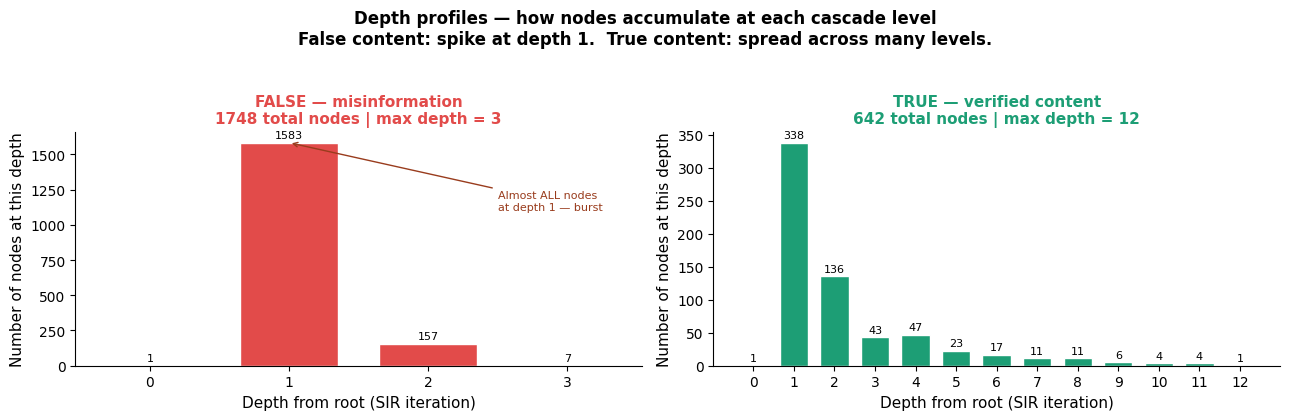

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/depth_profiles_false_vs_true.png


In [8]:
if contrast_loaded:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
    COLORS = {'false': '#E24B4A', 'true': '#1D9E75'}
    LABELS = {'false': 'FALSE — misinformation', 'true': 'TRUE — verified content'}

    for ax, label in zip(axes, ['false', 'true']):
        if label not in contrast_loaded:
            ax.set_visible(False)
            continue
        row, G, root = contrast_loaded[label]
        if root is None or root not in G:
            root = find_root(G)
        if root is None:
            ax.text(0.5, 0.5, 'No root found', ha='center', va='center',
                    transform=ax.transAxes)
            ax.axis('off')
            continue
        depths = nx.single_source_shortest_path_length(G, root)
        counts = Counter(depths.values())
        xs = sorted(counts.keys())
        ys = [counts[x] for x in xs]

        bars = ax.bar(xs, ys, color=COLORS[label], edgecolor='white', width=0.7)
        for bar, y in zip(bars, ys):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + max(ys)*0.01,
                    str(y), ha='center', va='bottom', fontsize=8)

        ax.set_xlabel('Depth from root (SIR iteration)', fontsize=11)
        ax.set_ylabel('Number of nodes at this depth', fontsize=11)
        ax.set_title(
            f'{LABELS[label]}\n'
            f'{G.number_of_nodes()} total nodes | max depth = {max(xs) if xs else 0}',
            fontsize=11, fontweight='bold', color=COLORS[label]
        )
        ax.spines[['top','right']].set_visible(False)
        ax.set_xticks(xs)

    # Annotate the key difference
    axes[0].annotate(
        'Almost ALL nodes\nat depth 1 — burst',
        xy=(1, max(Counter(nx.single_source_shortest_path_length(
                contrast_loaded['false'][1],
                find_root(contrast_loaded['false'][1],
                          contrast_loaded['false'][2])).values()).values())),
        xytext=(2.5, max(Counter(nx.single_source_shortest_path_length(
                contrast_loaded['false'][1],
                find_root(contrast_loaded['false'][1],
                          contrast_loaded['false'][2])).values()).values()) * 0.7),
        fontsize=8, color='#993C1D',
        arrowprops=dict(arrowstyle='->', color='#993C1D'),
    ) if 'false' in contrast_loaded else None

    plt.suptitle(
        'Depth profiles — how nodes accumulate at each cascade level\n'
        'False content: spike at depth 1.  True content: spread across many levels.',
        fontsize=12, fontweight='bold', y=1.04
    )
    plt.tight_layout()
    out = FIG_DIR / 'depth_profiles_false_vs_true.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved:', out)


## 6. Aggregate Evidence: Patterns Across All Cascades

The two trees above are single examples. The distributions below confirm these
patterns hold across **all Twitter15/16 cascades** (1,000+ false, 1,000+ true).

Key things to look for:
- **Max depth distribution**: the true distribution should have a longer right tail.
- **Max width distribution**: the false distribution should be shifted right.
- **Branching ratio**: false content should exceed the paper's α threshold more often,
  which is why the LP optimizer needs to constrain it.

The α = 1.5 vertical line marks the paper's default LP safety parameter (`cfg.lp.alpha`).
Content with branching ratio above this line would continue to spread if unaltered.


Twitter15/16 cascades: 563 false, 1133 true


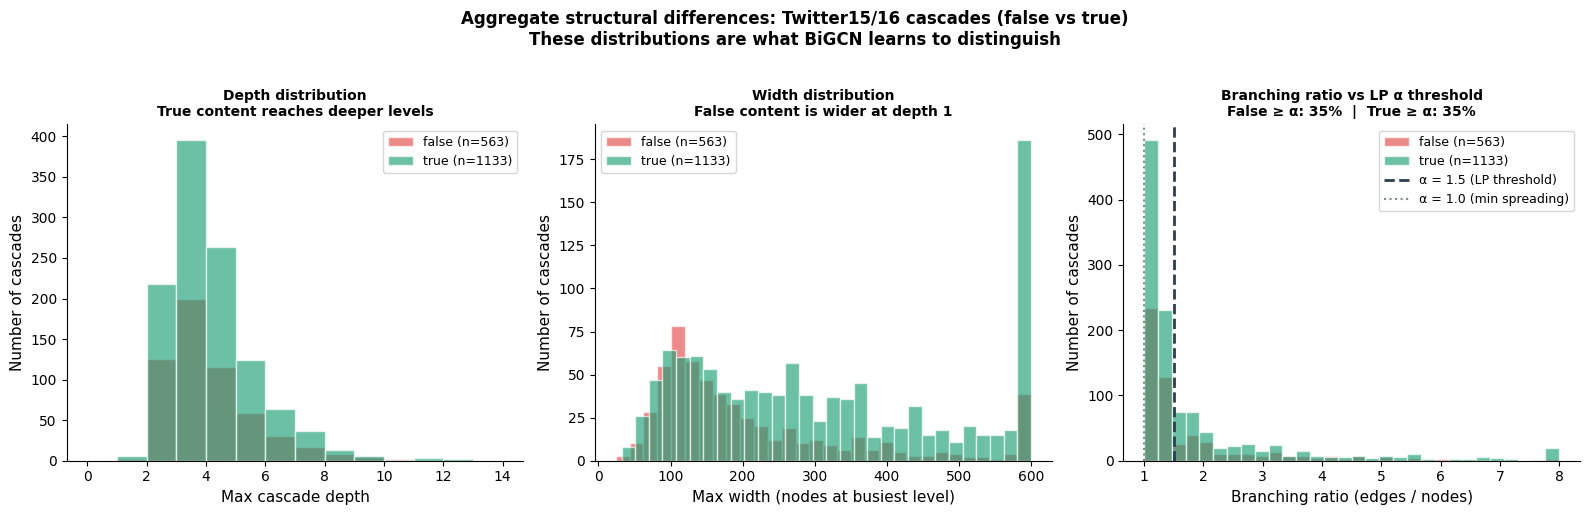

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/aggregate_distributions_false_vs_true.png

=== AGGREGATE STATISTICS (Twitter15 + Twitter16) ===


cascade_size              max_depth            max_width               \
              mean median   max      mean median max      mean median   max   
label                                                                         
false       313.91  210.0  1991      3.64    3.0  16    236.48  160.0  1583   
true        447.09  346.0  1987      3.68    3.0  12    352.88  277.0  1771   

      branching_ratio                
                 mean median    max  
label                                
false            2.34   1.26  225.0  
true             2.73   1.26  485.0

In [9]:
tw_df = tree_summary[
    tree_summary['dataset'].isin(['Twitter15','Twitter16']) &
    tree_summary['label'].isin(['true','false'])
].copy()

if tw_df.empty:
    print('No Twitter15/16 data in tree_summary. Run explore_data.ipynb with those datasets present.')
else:
    n_false = (tw_df['label'] == 'false').sum()
    n_true  = (tw_df['label'] == 'true').sum()
    print(f'Twitter15/16 cascades: {n_false} false, {n_true} true')

    C = {'false': '#E24B4A', 'true': '#1D9E75'}

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # ── Plot 1: max_depth distribution ───────────────────────────────────
    ax = axes[0]
    for label in ['false', 'true']:
        vals = tw_df[tw_df['label'].eq(label)]['max_depth'].dropna()
        ax.hist(vals, bins=range(0, 15), alpha=0.65, color=C[label],
                label=f'{label} (n={len(vals)})', edgecolor='white')
    ax.set_xlabel('Max cascade depth', fontsize=11)
    ax.set_ylabel('Number of cascades', fontsize=11)
    ax.set_title('Depth distribution\nTrue content reaches deeper levels',
                 fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines[['top','right']].set_visible(False)

    # ── Plot 2: max_width distribution ───────────────────────────────────
    ax = axes[1]
    for label in ['false', 'true']:
        vals = tw_df[tw_df['label'].eq(label)]['max_width'].dropna().clip(upper=600)
        ax.hist(vals, bins=30, alpha=0.65, color=C[label],
                label=f'{label} (n={len(vals)})', edgecolor='white')
    ax.set_xlabel('Max width (nodes at busiest level)', fontsize=11)
    ax.set_ylabel('Number of cascades', fontsize=11)
    ax.set_title('Width distribution\nFalse content is wider at depth 1',
                 fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines[['top','right']].set_visible(False)

    # ── Plot 3: branching ratio with α threshold ──────────────────────────
    ax = axes[2]
    alpha_val = float(cfg.lp.alpha)
    for label in ['false', 'true']:
        vals = tw_df[tw_df['label'].eq(label)]['branching_ratio'].dropna().clip(upper=8)
        ax.hist(vals, bins=30, alpha=0.65, color=C[label],
                label=f'{label} (n={len(vals)})', edgecolor='white')
    ax.axvline(alpha_val, color='#2C3E50', linestyle='--', linewidth=2,
               label=f'α = {alpha_val} (LP threshold)')
    ax.axvline(1.0, color='#7F8C8D', linestyle=':', linewidth=1.5,
               label='α = 1.0 (min spreading)')
    pct_f = 100*(tw_df[tw_df['label']=='false']['branching_ratio'] >= alpha_val).mean()
    pct_t = 100*(tw_df[tw_df['label']=='true']['branching_ratio']  >= alpha_val).mean()
    ax.set_xlabel('Branching ratio (edges / nodes)', fontsize=11)
    ax.set_ylabel('Number of cascades', fontsize=11)
    ax.set_title(
        f'Branching ratio vs LP α threshold\n'
        f'False ≥ α: {pct_f:.0f}%  |  True ≥ α: {pct_t:.0f}%',
        fontsize=10, fontweight='bold'
    )
    ax.legend(fontsize=9)
    ax.spines[['top','right']].set_visible(False)

    plt.suptitle(
        'Aggregate structural differences: Twitter15/16 cascades (false vs true)\n'
        'These distributions are what BiGCN learns to distinguish',
        fontsize=12, fontweight='bold', y=1.02
    )
    plt.tight_layout()
    out = FIG_DIR / 'aggregate_distributions_false_vs_true.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved:', out)

    # ── Summary statistics table ─────────────────────────────────────────
    print('\n=== AGGREGATE STATISTICS (Twitter15 + Twitter16) ===')
    agg = tw_df.groupby('label')[
        ['cascade_size','max_depth','max_width','branching_ratio']
    ].agg(['mean','median','max']).round(2)
    display(agg)


## 7. BiGCN Dual View: Why Both Directions Are Needed

BiGCN (Bi-directional Graph Convolutional Network) processes each cascade tree **twice**:

**Top-down (root → leaves):** models how the original claim fans out.
For false content this captures the wide burst at depth 1.

**Bottom-up (leaves → root):** models how community reaction aggregates back.
For true content this captures the long chain of deliberate re-endorsements flowing
back toward the source.

Using only top-down misses the response structure; using only bottom-up misses the spread
structure. The concatenation of both embeddings gives the classifier the full picture.


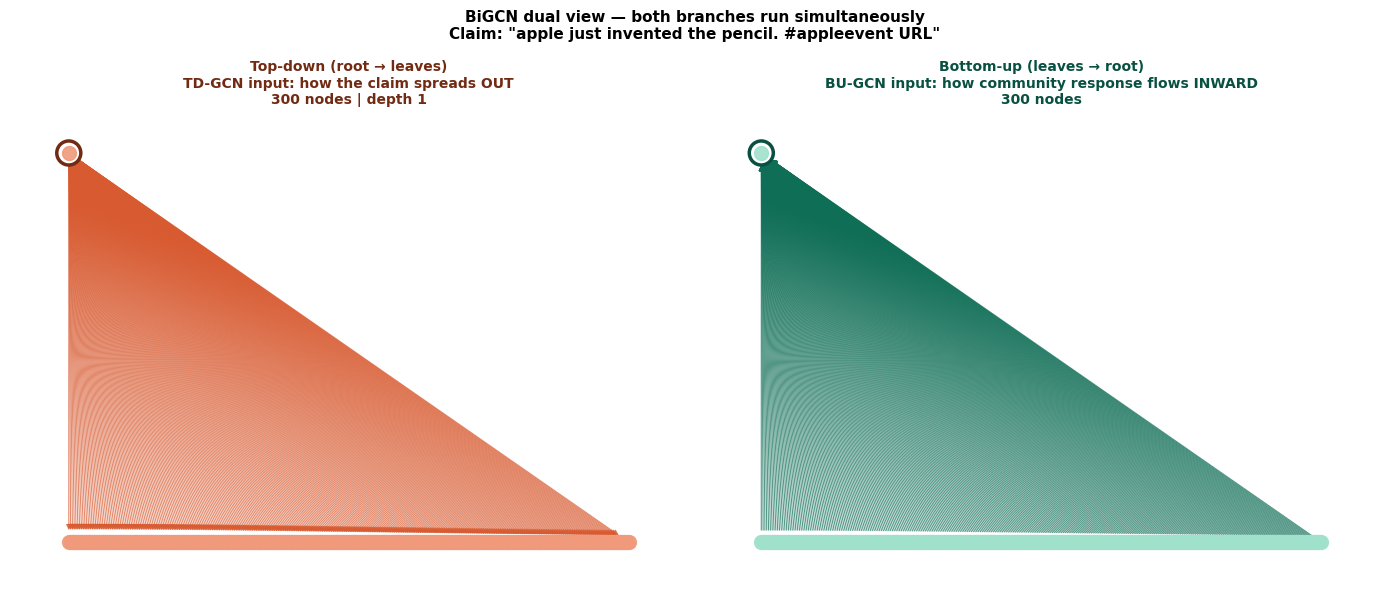

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/bigcn_dual_view.png

Top-down  → TD-GCN branch of BiGCN
Bottom-up → BU-GCN branch of BiGCN
Concatenated embeddings → final rumor-classification head


In [10]:
# Use the false example for the dual view (shows the clearest contrast)
dual_label = 'true' if 'true' in contrast_loaded else next(iter(contrast_loaded), None)

if dual_label:
    row, G_td, rid = contrast_loaded[dual_label]
    G_bu  = G_td.reverse()
    root  = find_root(G_td, rid)

    H_td, depths_td = depth_subgraph(G_td, root, max_nodes=300)
    pos = hierarchy_positions(H_td, root)
    H_bu = G_bu.subgraph(H_td.nodes()).copy()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.patch.set_facecolor('white')

    nx.draw_networkx_edges(H_td, pos, ax=ax1, edge_color='#D85A30',
                           arrows=True, arrowsize=8, width=0.8, alpha=0.7)
    nx.draw_networkx_nodes(H_td, pos, ax=ax1, node_color='#F0997B',
                           node_size=100, alpha=0.9)
    if root and root in pos:
        ax1.scatter(*pos[root], s=300, facecolors='none',
                    edgecolors='#712B13', linewidths=2.5, zorder=5)
    ax1.set_title(
        'Top-down (root → leaves)\n'
        'TD-GCN input: how the claim spreads OUT\n'
        f'{H_td.number_of_nodes()} nodes | depth {max(depths_td.values()) if depths_td else 0}',
        fontsize=10, fontweight='bold', color='#712B13'
    )
    ax1.axis('off')

    nx.draw_networkx_edges(H_bu, pos, ax=ax2, edge_color='#0F6E56',
                           arrows=True, arrowsize=8, width=0.8, alpha=0.7)
    nx.draw_networkx_nodes(H_bu, pos, ax=ax2, node_color='#9FE1CB',
                           node_size=100, alpha=0.9)
    if root and root in pos:
        ax2.scatter(*pos[root], s=300, facecolors='none',
                    edgecolors='#085041', linewidths=2.5, zorder=5)
    ax2.set_title(
        'Bottom-up (leaves → root)\n'
        'BU-GCN input: how community response flows INWARD\n'
        f'{H_bu.number_of_nodes()} nodes',
        fontsize=10, fontweight='bold', color='#085041'
    )
    ax2.axis('off')

    short = str(row.get('text',''))[:80]
    plt.suptitle(
        f'BiGCN dual view — both branches run simultaneously\n'
        f'Claim: "{short}"',
        fontsize=11, fontweight='bold'
    )
    plt.tight_layout()
    out = FIG_DIR / 'bigcn_dual_view.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved:', out)
    print()
    print('Top-down  → TD-GCN branch of BiGCN')
    print('Bottom-up → BU-GCN branch of BiGCN')
    print('Concatenated embeddings → final rumor-classification head')
else:
    print('No graphs loaded — run cell above first.')


## 8. Phase 1 Outputs

All figures are saved under `evaluation/tree_figures/`.

| File | Content |
|---|---|
| `showcase_false_vs_true_spreading.png` | **Main figure**: side-by-side depth-colored trees |
| `stats_comparison_false_vs_true.png` | Bar charts of nodes, depth, width, branching |
| `depth_profiles_false_vs_true.png` | Depth distribution histograms |
| `aggregate_distributions_false_vs_true.png` | Histograms across all Twitter15/16 cascades |
| `bigcn_dual_view.png` | Top-down vs bottom-up GCN input |

**What Phase 2 consumes from here:**

- `propagation_tree_summary.csv` → feature baselines for BiGCN training
- `contrast_tree_ids.csv` → the specific trees used in the showcase figure
- The branching ratio distributions → validate LP α feasibility before running Phase 3
